In [1]:
#models
library(tidyverse)
library(caret)
library(recipes)
library(pROC)
library(dplyr)
library(tidyr)
library(ppcor)


── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: lattice


Attaching package: ‘caret’


The following object is masked from ‘package:purrr’:

    lift



Attaching package: ‘recipes’


The following object is masked from ‘package:stringr’:

    fixed


The following object is masked from ‘package:stats’:

    step


Type 'citation("pROC")' for a citation.


Attaching packa

In [2]:
hpa_blood_pea <- read_tsv("../../data/blood_pea_disease_de.tsv")

Rows: 205674 Columns: 7
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (5): Gene, ENSG ID, Disease, Class, Control
dbl (2): logFC, p-value adjusted

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [3]:
protein_OR <- read_csv("../../data/Suppl-Proteomic-OR-Results.csv")

Rows: 93 Columns: 25
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr  (8): feature, display_label, Protein, suggested_symbol, Gene, gene_biot...
dbl (14): estimate, std.error, statistic, p.value, odds_ratio_sd, conf.low, ...
lgl  (3): sig_primary, sig_secondary, sig_flag

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [4]:
# Step 1: Get significant proteins from protein_OR
sig_proteins <- protein_OR %>%
  filter(sig_flag == TRUE) %>%
  pull(Gene_core)

# Check how many significant proteins we have
cat("Number of significant proteins:", length(sig_proteins), "\n")
cat("Significant proteins:", paste(sig_proteins, collapse = ", "), "\n")

# Step 2: Filter hpa_blood_pea for these proteins
hpa_sig <- hpa_blood_pea %>%
  filter(`ENSG ID` %in% sig_proteins)

# Check the result
cat("\nRows in filtered hpa_blood_pea:", nrow(hpa_sig), "\n")
cat("Unique genes found:", n_distinct(hpa_sig$Gene), "\n")

# Step 3: Check if any proteins weren't found
missing <- setdiff(sig_proteins, unique(hpa_sig$Gene))
if (length(missing) > 0) {
  cat("\nWARNING: These proteins were not found in hpa_blood_pea:\n")
  cat(paste(missing, collapse = ", "), "\n")
}


Number of significant proteins: 13 
Significant proteins: ENSG00000105388, ENSG00000262406, ENSG00000117560, ENSG00000168811, ENSG00000188389, ENSG00000136244, ENSG00000160223, ENSG00000178562, ENSG00000109943, ENSG00000145649, ENSG00000100450, ENSG00000096996, ENSG00000122223 

Rows in filtered hpa_blood_pea: 2301 
Unique genes found: 13 

ENSG00000105388, ENSG00000262406, ENSG00000117560, ENSG00000168811, ENSG00000188389, ENSG00000136244, ENSG00000160223, ENSG00000178562, ENSG00000109943, ENSG00000145649, ENSG00000100450, ENSG00000096996, ENSG00000122223 


In [5]:
library(tidyverse)
library(scales)
library(patchwork)

plot_protein_dotplot <- function(
  hpa_df,
  classes = c("Metabolic", "Cardiovascular", "Psychiatric"),
  control_group = "Healthy",
  reference = NULL,
  p_threshold = 0.05,
  max_size = 2.5,
  dot_size_range = c(2, 8),
  low_color = "#2166AC",
  mid_color = "#F7F7F7",
  high_color = "#B2182B",
  ns_color = "#CCCCCC"
) {
  
  # ---- Filter data ----
  plot_df <- hpa_df %>%
    filter(Control == control_group) %>%
    mutate(
      # Cap the absolute logFC for dot sizing
      size_fc = pmin(abs(logFC), max_size),
      # Determine significance
      is_sig = `p-value adjusted` < p_threshold,
      # Cap logFC for color scaling
      logFC_capped = pmin(pmax(logFC, -max_size), max_size)
    )
  
  # ---- Handle reference disease ----
  if (!is.null(reference)) {
    ref_df <- plot_df %>% filter(Disease == reference)
    if (nrow(ref_df) == 0) {
      warning(paste("Reference disease '", reference, "' not found in data. Skipping reference."))
      reference <- NULL
    }
  }
  
  # Filter to specified classes (excluding reference which is handled separately)
  class_df <- plot_df %>% filter(Class %in% classes)
  
  if (nrow(class_df) == 0 && is.null(reference)) {
    stop("No data remaining after filtering. Check your class names and control group.")
  }
  
  # ---- Build x-axis order ----
  x_order <- c()
  group_pos <- list()  # Will hold both reference and class positions
  pos <- 0
  
  # Add reference first if specified
  if (!is.null(reference)) {
    pos <- pos + 1
    x_id <- paste("Reference", reference, sep = "___")
    x_order <- c(x_order, x_id)
    
    # Add reference to plot_df with special class
    ref_df <- plot_df %>%
      filter(Disease == reference) %>%
      mutate(
        Class = "Reference",
        x_id = x_id
      )
    
    group_pos[[length(group_pos) + 1]] <- list(
      name = reference,
      start = 1,
      end = 1,
      mid = 1,
      is_reference = TRUE
    )
  }
  
  # Add classes
  for (cls in classes) {
    cls_df <- class_df %>% filter(Class == cls)
    if (nrow(cls_df) == 0) next
    
    cls_start <- pos + 1
    diseases_in_class <- cls_df %>%
      distinct(Disease) %>%
      pull(Disease) %>%
      sort()
    
    for (disease in diseases_in_class) {
      x_id <- paste(cls, disease, sep = "___")
      pos <- pos + 1
      x_order <- c(x_order, x_id)
    }
    
    cls_end <- pos
    if (cls_end >= cls_start) {
      group_pos[[length(group_pos) + 1]] <- list(
        name = cls,
        start = cls_start,
        end = cls_end,
        mid = (cls_start + cls_end) / 2,
        is_reference = FALSE
      )
    }
  }
  
  # ---- Combine reference and class data ----
  class_df <- class_df %>%
    mutate(x_id = paste(Class, Disease, sep = "___"))
  
  if (!is.null(reference)) {
    plot_df <- bind_rows(ref_df, class_df)
  } else {
    plot_df <- class_df
  }
  
  # ---- Prepare final plot data ----
  plot_df <- plot_df %>%
    filter(x_id %in% x_order) %>%
    mutate(x_id = factor(x_id, levels = x_order))
  
  # X-axis labels (just the disease name)
  x_labels <- plot_df %>%
    distinct(x_id, Disease) %>%
    deframe()
  
  # Y-axis: genes in order
  gene_order <- plot_df %>%
    distinct(Gene) %>%
    arrange(Gene) %>%
    pull(Gene)
  
  plot_df$Gene <- factor(plot_df$Gene, levels = gene_order)
  
  n_genes <- length(gene_order)
  n_x <- length(x_order)
  
  # ---- Create plot ----
  p <- ggplot(plot_df, aes(x = x_id, y = Gene)) +
    # Non-significant points (grey)
    geom_point(
      data = plot_df %>% filter(!is_sig),
      aes(size = size_fc),
      fill = ns_color, shape = 21, color = "black", stroke = 0.5
    ) +
    # Significant points (gradient)
    geom_point(
      data = plot_df %>% filter(is_sig),
      aes(size = size_fc, fill = logFC_capped),
      shape = 21, color = "black", stroke = 0.5
    ) +
    scale_x_discrete(labels = x_labels) +
    scale_y_discrete(limits = rev) +
    scale_fill_gradient2(
      low = low_color,
      mid = mid_color,
      high = high_color,
      midpoint = 0,
      limits = c(-max_size, max_size),
      name = "log2FC",
      guide = guide_colorbar(order = 1)
    ) +
    scale_size_continuous(
      range = dot_size_range,
      limits = c(0, max_size),
      breaks = seq(0.5, max_size, by = 0.5),
      name = "|log2FC|"
    ) +
    labs(x = NULL, y = NULL) +
    theme_minimal(base_size = 14) +
    theme(
      axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1, size = 9),
      axis.text.y = element_text(size = 11),
      panel.grid.major = element_line(color = "grey92", linewidth = 0.3),
      panel.grid.minor = element_blank(),
      panel.border = element_blank(),
      legend.position = "right",
      plot.margin = margin(50, 10, 10, 10)
    ) +
    guides(
      size = guide_legend(order = 2)
    ) +
    coord_cartesian(clip = "off")
  
  # ---- Add header annotations ----
  for (grp in group_pos) {
    p <- p +
      annotate(
        "segment",
        x = grp$start - 0.4, xend = grp$end + 0.4,
        y = n_genes + 0.6, yend = n_genes + 0.6,
        color = ifelse(grp$is_reference, "#B2182B", "black"),
        linewidth = 1
      ) +
      annotate(
        "text",
        x = grp$mid, y = n_genes + 1.1,
        label = grp$name,
        hjust = 0.5, vjust = 0, size = 4.5,
        color = ifelse(grp$is_reference, "#B2182B", "black")
      )
  }
  
  # ---- Add vertical separators between groups ----
  if (length(group_pos) > 1) {
    for (i in seq_along(group_pos)[-length(group_pos)]) {
      sep_x <- group_pos[[i]]$end + 0.5
      p <- p +
        annotate(
          "segment",
          x = sep_x, xend = sep_x,
          y = 0.5, yend = n_genes + 0.5,
          color = "grey50", linewidth = 0.8, linetype = "dashed"
        )
    }
  }
  
  p
}

# ---- Usage ----
options(repr.plot.width = 22, repr.plot.height = 12, repr.plot.res = 250)

p <- plot_protein_dotplot(
  hpa_df = hpa_sig,
  classes = c("Cancer", "Cardiovascular", "Autoimmune"),
  control_group = "Healthy",
  reference = "Lung cancer",
  p_threshold = 0.05,
  max_size = 2
)




Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor



Attaching package: ‘patchwork’


The following object is masked from ‘package:MASS’:

    area




LUCAS data: found 13 matching genes


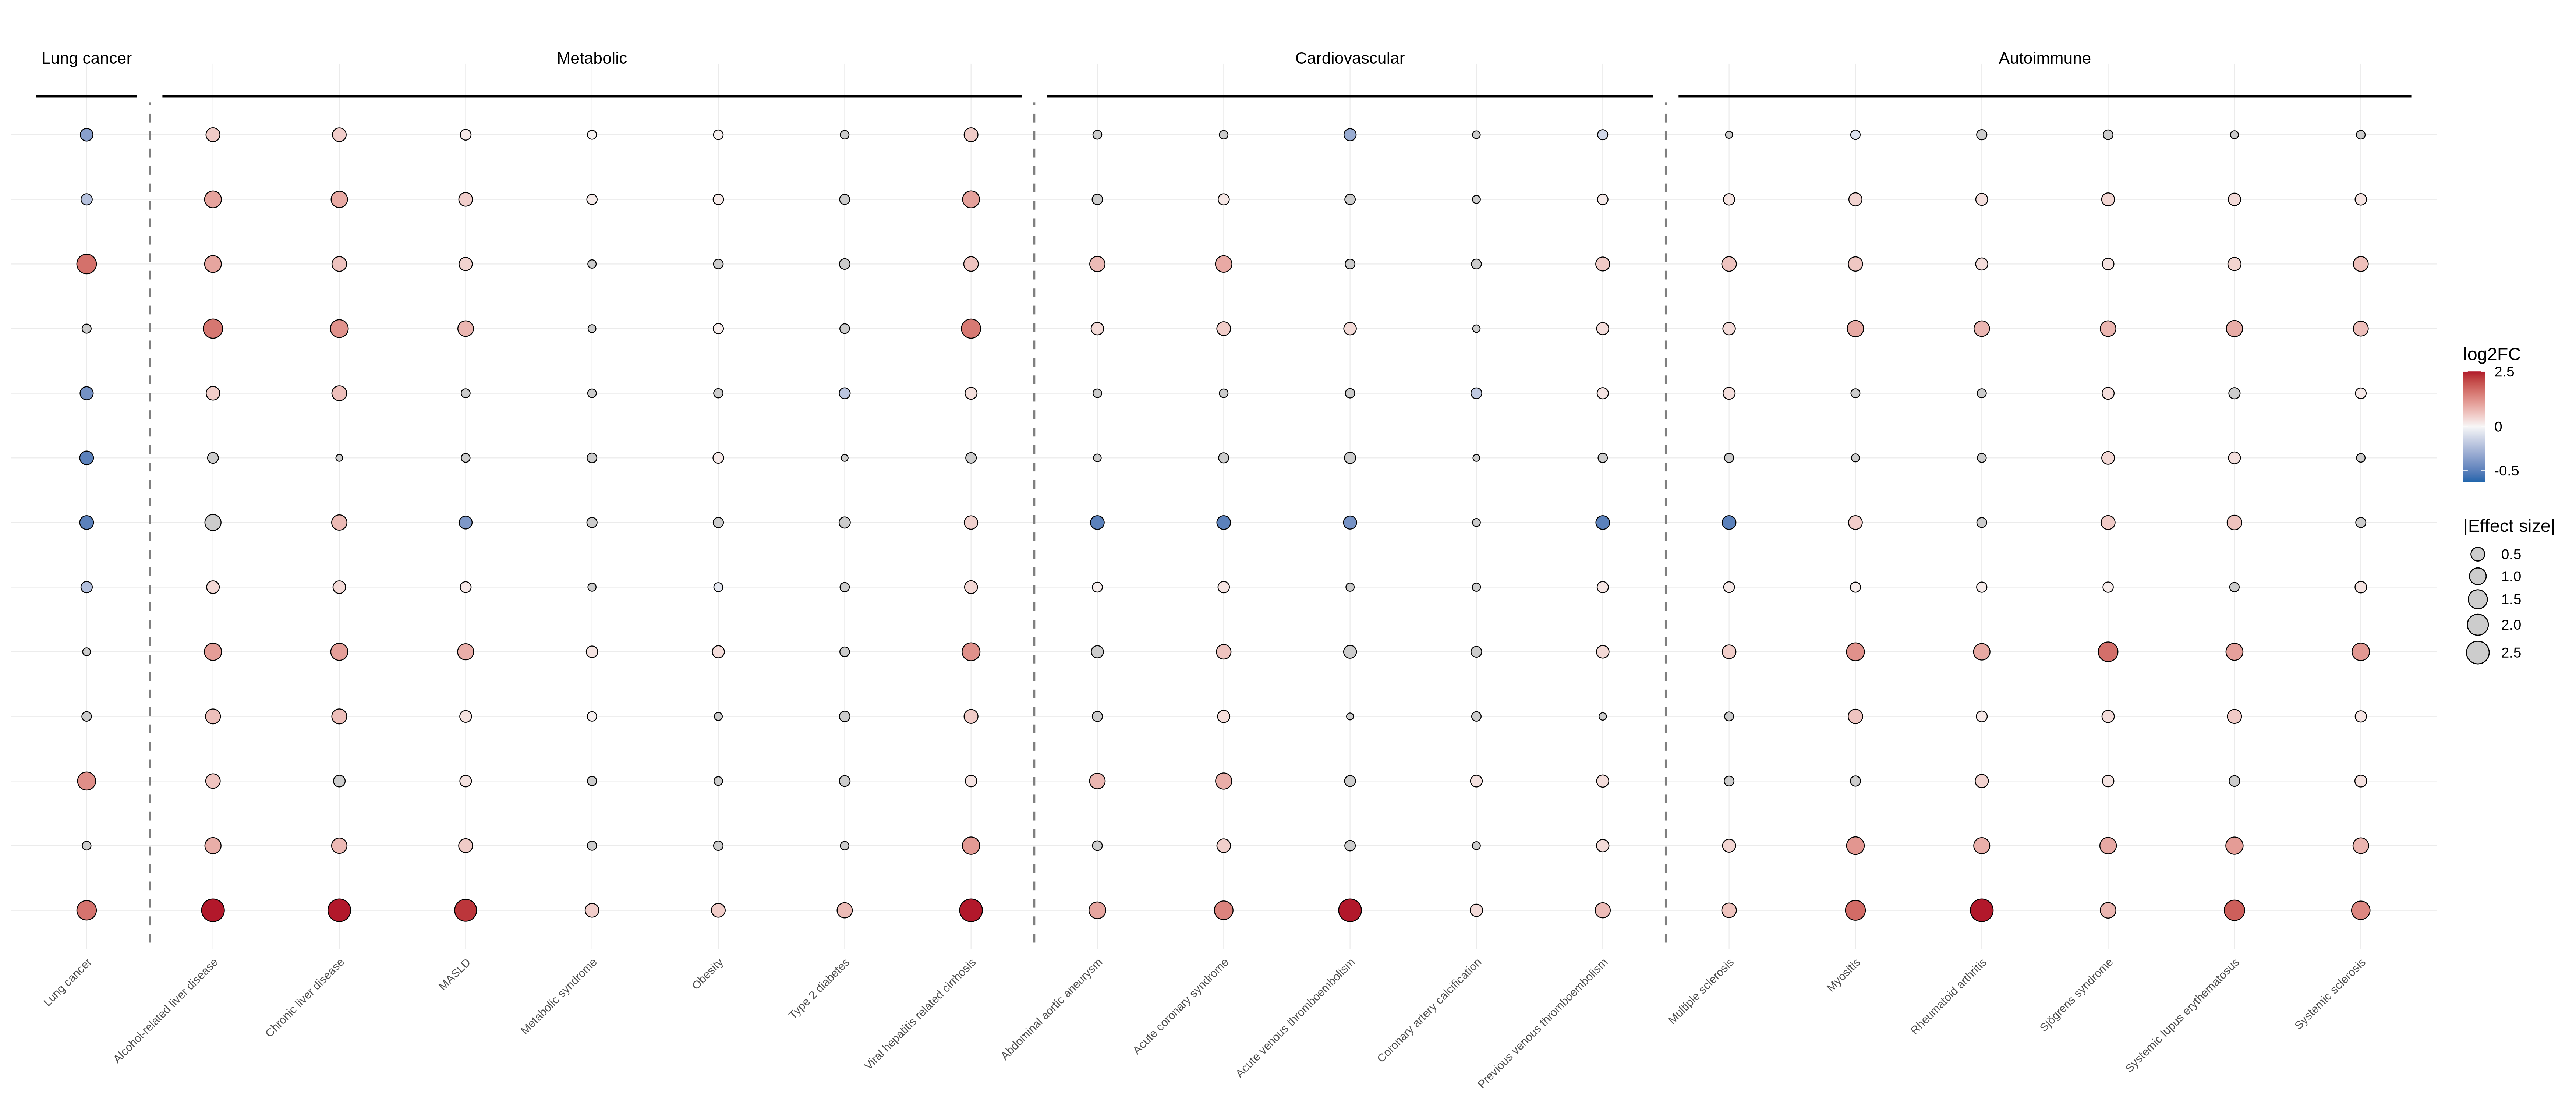

In [6]:
library(tidyverse)
library(scales)
library(patchwork)

plot_protein_dotplot <- function(
  hpa_df,
  lucas_df = NULL,
  classes = c("Metabolic", "Cardiovascular", "Psychiatric"),
  control_group = "Healthy",
  reference = NULL,
  p_threshold = 0.05,
  max_size_pos = 2.5,
  max_size_neg = 2.5,
  dot_size_range = c(2, 8),
  low_color = "#2166AC",
  mid_color = "#F7F7F7",
  high_color = "#B2182B",
  ns_color = "#CCCCCC",
  lollipop_width = 0.15,
  color_scale_neg = 1.0,
  color_scale_pos = 1.0
) {
  
  # ---- Helper function to cap values asymmetrically ----
  cap_values <- function(x, max_pos, max_neg) {
    pmin(pmax(x, -max_neg), max_pos)
  }
  
  # ---- Helper function to rescale values for color mapping ----
  rescale_for_color <- function(x, scale_neg, scale_pos) {
    ifelse(x < 0, x * scale_neg, x * scale_pos)
  }
  
  # ---- Filter HPA data ----
  plot_df <- hpa_df %>%
    filter(Control == control_group) %>%
    mutate(
      logFC_capped = cap_values(logFC, max_size_pos, max_size_neg),
      size_fc = abs(logFC_capped),
      is_sig = `p-value adjusted` < p_threshold,
      logFC_color = rescale_for_color(logFC_capped, color_scale_neg, color_scale_pos)
    )
  
  # Calculate color limits based on scaling
  color_limit_neg <- max_size_neg * color_scale_neg
  color_limit_pos <- max_size_pos * color_scale_pos
  color_limit_max <- max(color_limit_neg, color_limit_pos)
  
  # Max for size scale
  max_size_overall <- max(max_size_pos, max_size_neg)
  
  # ---- Build x-axis order ----
  x_order <- c()
  group_pos <- list()
  pos <- 0
  
  # ---- Prepare LUCAS data for lollipop plot ----
  lucas_plot_df <- NULL
  if (!is.null(lucas_df)) {
    ensg_in_hpa <- unique(plot_df$`ENSG ID`)
    
    lucas_plot_df <- lucas_df %>%
      filter(Gene_core %in% ensg_in_hpa) %>%
      mutate(
        `ENSG ID` = Gene_core,
        estimate_capped = cap_values(statistic, max_size_pos, max_size_neg),
        is_sig = p.value < p_threshold,
        estimate_color = rescale_for_color(estimate_capped, color_scale_neg, color_scale_pos)
      )
    
    # Get Gene names from hpa_df for the matching ENSG IDs
    ensg_to_gene <- plot_df %>%
      distinct(`ENSG ID`, Gene) %>%
      deframe()
    
    lucas_plot_df <- lucas_plot_df %>%
      mutate(Gene = ensg_to_gene[`ENSG ID`])
    
    if (nrow(lucas_plot_df) > 0) {
      cat("LUCAS data: found", nrow(lucas_plot_df), "matching genes\n")
    } else {
      cat("WARNING: No matching genes found between lucas_df and hpa_df\n")
    }
  }
  
  # ---- Handle reference disease ----
  ref_df <- NULL
  if (!is.null(reference)) {
    ref_df <- plot_df %>% filter(Disease == reference)
    if (nrow(ref_df) == 0) {
      warning(paste("Reference disease '", reference, "' not found in data. Skipping reference."))
      reference <- NULL
    } else {
      pos <- pos + 1
      x_id <- paste("Reference", reference, sep = "___")
      x_order <- c(x_order, x_id)
      
      ref_df <- ref_df %>%
        mutate(
          Class = "Reference",
          x_id = x_id
        )
      
      group_pos[[length(group_pos) + 1]] <- list(
        name = reference,
        start = pos,
        end = pos,
        mid = pos,
        type = "reference"
      )
    }
  }
  
  # ---- Handle classes ----
  diseases_to_exclude <- c("LUCAS")
  if (!is.null(reference)) {
    diseases_to_exclude <- c(diseases_to_exclude, reference)
  }
  
  class_df <- plot_df %>% 
    filter(
      Class %in% classes,
      !Disease %in% diseases_to_exclude
    )
  
  if (nrow(class_df) == 0 && is.null(reference)) {
    stop("No data remaining after filtering. Check your class names and control group.")
  }
  
  for (cls in classes) {
    cls_df <- class_df %>% filter(Class == cls)
    if (nrow(cls_df) == 0) next
    
    cls_start <- pos + 1
    diseases_in_class <- cls_df %>%
      distinct(Disease) %>%
      pull(Disease) %>%
      sort()
    
    for (disease in diseases_in_class) {
      x_id <- paste(cls, disease, sep = "___")
      pos <- pos + 1
      x_order <- c(x_order, x_id)
    }
    
    cls_end <- pos
    if (cls_end >= cls_start) {
      group_pos[[length(group_pos) + 1]] <- list(
        name = cls,
        start = cls_start,
        end = cls_end,
        mid = (cls_start + cls_end) / 2,
        type = "class"
      )
    }
  }
  
  # ---- Combine all data ----
  class_df <- class_df %>%
    mutate(x_id = paste(Class, Disease, sep = "___"))
  
  combined_df <- class_df
  
  if (!is.null(ref_df)) {
    combined_df <- bind_rows(ref_df, combined_df)
  }
  
  # ---- Prepare final plot data ----
  plot_df <- combined_df %>%
    filter(x_id %in% x_order) %>%
    mutate(x_id = factor(x_id, levels = x_order))
  
  # X-axis labels (just the disease name)
  x_labels <- plot_df %>%
    distinct(x_id, Disease) %>%
    deframe()
  
  # Y-axis: genes in order
  gene_order <- plot_df %>%
    distinct(Gene) %>%
    arrange(Gene) %>%
    pull(Gene)
  
  plot_df$Gene <- factor(plot_df$Gene, levels = gene_order)
  
  n_genes <- length(gene_order)
  n_x <- length(x_order)
  
  # ---- Create dotplot ----
  p_dot <- ggplot(plot_df, aes(x = x_id, y = Gene)) +
    # Non-significant points (grey)
    geom_point(
      data = plot_df %>% filter(!is_sig),
      aes(size = size_fc),
      fill = ns_color, shape = 21, color = "black", stroke = 0.5
    ) +
    # Significant points (gradient)
    geom_point(
      data = plot_df %>% filter(is_sig),
      aes(size = size_fc, fill = logFC_color),
      shape = 21, color = "black", stroke = 0.5
    ) +
    scale_x_discrete(labels = x_labels) +
    scale_y_discrete(limits = rev) +
    scale_fill_gradient2(
      low = low_color,
      mid = mid_color,
      high = high_color,
      midpoint = 0,
      limits = c(-color_limit_max, color_limit_max),
      name = "log2FC",
      guide = guide_colorbar(order = 1),
      breaks = c(-color_limit_neg, 0, color_limit_pos),
      labels = c(round(-max_size_neg, 1), 0, round(max_size_pos, 1))
    ) +
    scale_size_continuous(
      range = dot_size_range,
      limits = c(0, max_size_overall),
      breaks = seq(0.5, max_size_overall, by = 0.5),
      name = "|Effect size|"
    ) +
    labs(x = NULL, y = NULL) +
    theme_minimal(base_size = 14) +
    theme(
      axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1, size = 9),
      axis.text.y = element_blank(),
      axis.ticks.y = element_blank(),
      panel.grid.major = element_line(color = "grey92", linewidth = 0.3),
      panel.grid.minor = element_blank(),
      panel.border = element_blank(),
      legend.position = "right",
      plot.margin = margin(50, 10, 10, 5)
    ) +
    guides(
      size = guide_legend(order = 2)
    ) +
    coord_cartesian(clip = "off")
  
  # ---- Add header annotations to dotplot ----
  header_colors <- c(
    reference = "black",
    class = "black"
  )
  
  for (grp in group_pos) {
    p_dot <- p_dot +
      annotate(
        "segment",
        x = grp$start - 0.4, xend = grp$end + 0.4,
        y = n_genes + 0.6, yend = n_genes + 0.6,
        color = header_colors[[grp$type]],
        linewidth = 1
      ) +
      annotate(
        "text",
        x = grp$mid, y = n_genes + 1.1,
        label = grp$name,
        hjust = 0.5, vjust = 0, size = 4.5,
        color = header_colors[[grp$type]]
      )
  }
  
  # ---- Add vertical separators between groups ----
  if (length(group_pos) > 1) {
    for (i in seq_along(group_pos)[-length(group_pos)]) {
      sep_x <- group_pos[[i]]$end + 0.5
      p_dot <- p_dot +
        annotate(
          "segment",
          x = sep_x, xend = sep_x,
          y = 0.5, yend = n_genes + 0.5,
          color = "grey50", linewidth = 0.8, linetype = "dashed"
        )
    }
  }
  
  # ---- Create lollipop plot for LUCAS (on the LEFT) ----
  if (!is.null(lucas_plot_df) && nrow(lucas_plot_df) > 0) {
    
    lucas_plot_df$Gene <- factor(lucas_plot_df$Gene, levels = gene_order)
    
    # Use asymmetric x-axis limits
    x_limit_pos <- max_size_pos + 0.2
    x_limit_neg <- max_size_neg + 0.2
    
    p_lollipop <- ggplot(lucas_plot_df, aes(x = estimate_capped, y = Gene)) +
      # Vertical line at 0
      geom_vline(xintercept = 0, color = "grey50", linetype = "dashed", linewidth = 0.5) +
      # Segments (stems)
      geom_segment(
        aes(x = 0, xend = estimate_capped, y = Gene, yend = Gene, color = estimate_color),
        linewidth = 1.2
      ) +
      # Points (dots) - non-significant
      geom_point(
        data = lucas_plot_df %>% filter(!is_sig),
        aes(x = estimate_capped, y = Gene),
        fill = ns_color, color = "black", size = 4, shape = 21, stroke = 0.5
      ) +
      # Points (dots) - significant
      geom_point(
        data = lucas_plot_df %>% filter(is_sig),
        aes(x = estimate_capped, y = Gene, fill = estimate_color),
        color = "black", size = 4, shape = 21, stroke = 0.5
      ) +
      scale_y_discrete(limits = rev, drop = FALSE) +
      scale_x_continuous(
        limits = c(-x_limit_neg, x_limit_pos),
        breaks = scales::pretty_breaks(n = 5)
      ) +
      scale_color_gradient2(
        low = low_color,
        mid = mid_color,
        high = high_color,
        midpoint = 0,
        limits = c(-color_limit_max, color_limit_max),
        guide = "none"
      ) +
      scale_fill_gradient2(
        low = low_color,
        mid = mid_color,
        high = high_color,
        midpoint = 0,
        limits = c(-color_limit_max, color_limit_max),
        guide = "none"
      ) +
      labs(x = "Wald statistic", y = NULL) +
      theme_minimal(base_size = 14) +
      theme(
        axis.text.y = element_text(size = 11),
        axis.text.x = element_text(size = 9),
        panel.grid.major.y = element_blank(),
        panel.grid.minor = element_blank(),
        panel.grid.major.x = element_line(color = "grey92", linewidth = 0.3),
        plot.margin = margin(50, 5, 10, 10)
      ) +
      coord_cartesian(clip = "off") +
      # Add LUCAS header
      annotate(
        "segment",
        x = -x_limit_neg * 0.8, xend = x_limit_pos * 0.8,
        y = n_genes + 0.6, yend = n_genes + 0.6,
        color = "black",
        linewidth = 1
      ) +
      annotate(
        "text",
        x = 0, y = n_genes + 1.1,
        label = "LUCAS",
        hjust = 0.5, vjust = 0, size = 4.5,
        color = "black"
      )
    
    # Combine plots: LOLLIPOP on LEFT, DOTPLOT on RIGHT
    combined_plot <- p_dot
    
    return(combined_plot)
    
  } else {
    return(p_dot)
  }
}

# ---- Usage ----
options(repr.plot.width = 28, repr.plot.height = 12, repr.plot.res = 250)

p <- plot_protein_dotplot(
  hpa_df = hpa_sig,
  lucas_df = protein_OR,
  classes = c("Metabolic", "Cardiovascular", "Autoimmune"),
  control_group = "Healthy",
  reference = "Lung cancer",
  p_threshold = 0.05,
  max_size_pos = 2.5,
  max_size_neg = 0.5,
  lollipop_width = 0.15,
  color_scale_neg = 4.0,
  color_scale_pos = 1.0
)
p



In [7]:
# # Save as PNG
ggsave(
  filename = "../../outputs/Extended/Ext-Fig-2a-Protein-Clinical-Enrichment.png",
  plot = p,
  width = 28,
  height = 12,
  dpi = 300,
  units = "in",
    create.dir = TRUE
)

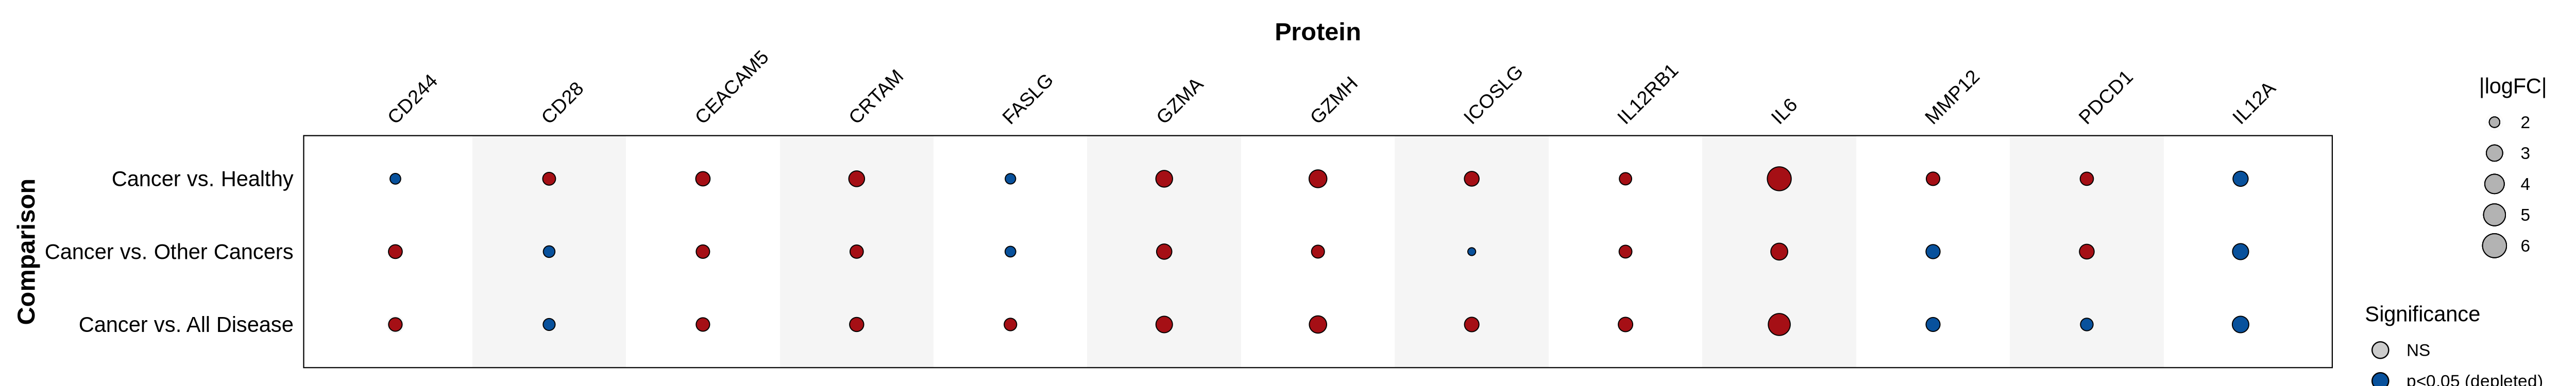

In [8]:
library(tidyverse)
library(scales)
library(ggnewscale)

plot_hpa_dotplot_horizontal <- function(
  hpa_df,
  sig_proteins = NULL,
  categories = c("Healthy", "Class", "All other diseases"),
  category_labels = c("Cancer vs. Healthy", "Cancer vs. Other Cancers", "Cancer vs. All Disease"),
  pea_sig_thresh = 0.05,
  size_cap_neglog10 = 10,
  size_range = c(1.8, 6),
  enriched_color_low = "#FDE0DD",
  enriched_color_high = "#A50F15",
  depleted_color_low = "#DEEBF7",
  depleted_color_high = "#08519C",
  ns_color = "grey80",
  stripe_color = "#f5f5f5"
) {
  
  # ---- Get proteins to include ----
  if (is.null(sig_proteins)) {
    stop("Please provide sig_proteins (e.g., unique(hpa_sig$Gene))")
  }
  
  # ---- Filter and prepare data ----
  pea_df <- hpa_df %>%
    rename(padj = `p-value adjusted`, Category = Control) %>%
    mutate(
      Gene = as.character(Gene),
      Category = as.character(Category)
    ) %>%
    filter(
      Gene %in% sig_proteins,
      Category %in% categories
    )
  
  # Keep one row per (Gene, Category) - lowest p-value
  pea_agg <- pea_df %>%
    mutate(padj_repl = ifelse(is.na(padj), Inf, padj)) %>%
    group_by(Gene, Category) %>%
    slice_min(order_by = padj_repl, n = 1, with_ties = FALSE) %>%
    ungroup() %>%
    dplyr::select(-padj_repl)
  
  # ---- Complete the grid ----
  dot_df <- pea_agg %>%
    complete(Gene = sig_proteins, Category = categories) %>%
    mutate(
      sig = !is.na(padj) & padj < pea_sig_thresh,
      neglog10 = ifelse(!is.na(padj), -log10(padj), 0),
      neglog10_capped = pmin(neglog10, size_cap_neglog10),
      abs_logFC = abs(logFC)
    )
  
  # ---- Size by |logFC| ----
  max_abs <- ifelse(
    all(is.na(dot_df$abs_logFC) | dot_df$abs_logFC == 0), 
    1,
    max(dot_df$abs_logFC, na.rm = TRUE)
  )
  
  dot_df <- dot_df %>%
    mutate(size_val = rescale(replace_na(abs_logFC, 0), to = size_range, from = c(0, max_abs)))
  
  # ---- Order genes alphabetically and set up factors ----
  gene_order <- sort(unique(dot_df$Gene))
  dot_df$Gene <- factor(dot_df$Gene, levels = gene_order)
  dot_df$Category <- factor(
    dot_df$Category,
    levels = categories,
    labels = category_labels
  )
  
  # ---- Create vertical stripes (for horizontal plot, stripes are vertical) ----
  stripe_df <- dot_df %>%
    distinct(Gene) %>%
    arrange(factor(Gene, levels = gene_order)) %>%
    mutate(
      idx = row_number(),
      stripe = if_else(idx %% 2 == 0, "stripe", "plain"),
      xmin = idx - 0.5,
      xmax = idx + 0.5
    )
  
  # ---- Split by sign/significance ----
  pos_sig <- dot_df %>% filter(sig, !is.na(logFC), logFC > 0)
  neg_sig <- dot_df %>% filter(sig, !is.na(logFC), logFC < 0)
  ns_df <- dot_df %>% filter(!sig | is.na(logFC))
  
  # ---- Legend for significance ----
  legend_df <- data.frame(sig_label = c("NS", "p<0.05 (depleted)", "p<0.05 (enriched)"))
  geom_legend <- geom_point(
    data = legend_df,
    inherit.aes = FALSE,
    aes(x = 1, y = 1, shape = sig_label),
    size = 4, alpha = 0.01, show.legend = TRUE
  )
  shape_scale <- scale_shape_manual(
    name = "Significance",
    breaks = c("NS", "p<0.05 (depleted)", "p<0.05 (enriched)"),
    values = c(21, 21, 21),
    guide = guide_legend(
      order = 2,
      override.aes = list(
        fill = c(ns_color, depleted_color_high, enriched_color_high),
        color = "black",
        size = 4,
        alpha = 1
      )
    )
  )
  
  # ---- Create horizontal dotplot (proteins on x-axis, categories on y-axis) ----
  p <- ggplot(dot_df, aes(x = Gene, y = Category)) +
    # Vertical stripes
    geom_rect(
      data = stripe_df,
      aes(xmin = xmin, xmax = xmax, ymin = -Inf, ymax = Inf, fill = stripe),
      inherit.aes = FALSE, show.legend = FALSE
    ) +
    scale_fill_manual(values = c("stripe" = stripe_color, "plain" = "white"), guide = "none") +
    ggnewscale::new_scale_fill() +
    # Non-significant points
    geom_point(
      data = ns_df,
      aes(size = size_val),
      shape = 21, fill = ns_color, color = "black", stroke = 0.4
    ) +
    # Positive significant (enriched) - red gradient
    geom_point(
      data = pos_sig,
      aes(fill = neglog10_capped, size = size_val),
      shape = 21, color = "black", stroke = 0.4
    ) +
    scale_fill_gradient(
      limits = c(0, size_cap_neglog10),
      low = enriched_color_low, 
      high = enriched_color_high, 
      guide = "none"
    ) +
    ggnewscale::new_scale_fill() +
    # Negative significant (depleted) - blue gradient
    geom_point(
      data = neg_sig,
      aes(fill = neglog10_capped, size = size_val),
      shape = 21, color = "black", stroke = 0.4
    ) +
    scale_fill_gradient(
      limits = c(0, size_cap_neglog10),
      low = depleted_color_low, 
      high = depleted_color_high, 
      guide = "none"
    ) +
    # Size legend
    scale_size_continuous(
      name = "|logFC|",
      range = size_range,
      guide = guide_legend(order = 1, override.aes = list(shape = 21, fill = "grey70", color = "black"))
    ) +
    # Significance legend
    geom_legend + 
    shape_scale +
    # Axis settings
    scale_x_discrete(position = "top") +
    scale_y_discrete(limits = rev(category_labels)) +
    # Theme
    theme_minimal(base_size = 12) +
    theme(
      legend.position = "right",
      axis.text.x = element_text(size = 11, color = "black", angle = 45, hjust = 0, vjust = 0.5),
      axis.text.y = element_text(size = 12, color = "black"),
      axis.title.x = element_text(size = 14, face = "bold"),
      axis.title.y = element_text(size = 14, face = "bold"),
      panel.border = element_rect(color = "black", fill = NA, linewidth = 0.6),
      panel.grid = element_blank(),
      axis.ticks = element_blank(),
      plot.margin = margin(10, 10, 10, 10),
      legend.box = "vertical",
      legend.box.just = "right"
    ) +
    labs(x = "Protein", y = "Comparison")
  
  return(list(
    plot = p,
    data = dot_df,
    gene_order = gene_order
  ))
}

# ---- Usage ----
options(repr.plot.width = 20, repr.plot.height = 3, repr.plot.res = 250)

# Get significant proteins from hpa_sig
sig_proteins <- unique(hpa_sig$Gene)

result <- plot_hpa_dotplot_horizontal(
  hpa_df = hpa_blood_pea,
  sig_proteins = sig_proteins,
  categories = c("Healthy", "Class", "All other diseases"),
  category_labels = c("Cancer vs. Healthy", "Cancer vs. Other Cancers", "Cancer vs. All Disease"),
  pea_sig_thresh = 0.05,
  size_cap_neglog10 = 10,
  size_range = c(1.8, 6)
)

print(result$plot)



In [9]:
# Save as PNG
ggsave(
  filename = "../../outputs/Extended/Ext-Fig-2b-Protein-Control-vs-plot.png",
  plot = result$plot,
  width = 20,
  height = 3,
  dpi = 600,
  units = "in",
    create.dir = TRUE
)

In [ ]:
# Done #